In [15]:
import numpy as np
from scipy.stats import pearson3
import matplotlib as plt 
import pandas as pd

In [16]:
df = pd.read_csv('storms.csv', na_values = [-999, -9999])
df.head()

,name,year,month,day,hour,lat,long,status,category,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter
0,AL011975,1975,6,24,12,32.5,-52.0,tropical depression,NaN,20,NaN,-1998,-1998
1,AL011975,1975,6,24,18,32.6,-52.6,tropical depression,NaN,25,NaN,-1998,-1998
2,AL011975,1975,6,25,0,32.7,-53.2,tropical depression,NaN,25,NaN,-1998,-1998
3,AL011975,1975,6,25,60,32.8,-53.2,tropical depression,NaN,25,NaN,-1998,-1998
4,AL011975,1975,6,25,12,33.0,-54.5,tropical depression,NaN,25,NaN,-1998,-1998


In [17]:
df2 = df.loc[df['status'] == 'hurricane']
df2.head(25)

,name,year,month,day,hour,lat,long,status,category,wind,pressure,tropicalstorm_force_diameter,hurricane_force_diameter
70,Blanche,1975,7,27,60,35.9,-70.0,hurricane,1.0,65,987.0,-1998,-1998
71,Blanche,1975,7,27,12,36.9,-69.0,hurricane,1.0,70,984.0,-1998,-1998
72,Blanche,1975,7,27,18,37.9,-68.0,hurricane,1.0,75,981.0,-1998,-1998
73,Blanche,1975,7,28,0,39.3,-67.2,hurricane,1.0,75,980.0,-1998,-1998
74,Blanche,1975,7,28,60,41.2,-66.4,hurricane,1.0,70,980.0,-1998,-1998
115,Caroline,1975,8,30,0,23.3,-94.2,hurricane,1.0,65,990.0,-1998,-1998
116,Caroline,1975,8,30,60,23.5,-94.9,hurricane,1.0,65,990.0,-1998,-1998
117,Caroline,1975,8,30,12,23.7,-95.6,hurricane,1.0,65,989.0,-1998,-1998
118,Caroline,1975,8,30,18,23.8,-96.3,hurricane,1.0,70,987.0,-1998,-1998
119,Caroline,1975,8,31,0,24.0,-97.0,hurricane,3.0,100,973.0,-1998,-1998


In [18]:
df2.columns

Index(['name', 'year', 'month', 'day', 'hour', 'lat', 'long', 'status',
       'category', 'wind', 'pressure', 'tropicalstorm_force_diameter',
       'hurricane_force_diameter'],
      dtype='str')

In [19]:
df2 = df2.drop(columns= ['hurricane_force_diameter', 'tropicalstorm_force_diameter'])
df2.head()

,name,year,month,day,hour,lat,long,status,category,wind,pressure
70,Blanche,1975,7,27,60,35.9,-70.0,hurricane,1.0,65,987.0
71,Blanche,1975,7,27,12,36.9,-69.0,hurricane,1.0,70,984.0
72,Blanche,1975,7,27,18,37.9,-68.0,hurricane,1.0,75,981.0
73,Blanche,1975,7,28,0,39.3,-67.2,hurricane,1.0,75,980.0
74,Blanche,1975,7,28,60,41.2,-66.4,hurricane,1.0,70,980.0


In [20]:
df2['category'].unique(), df2['wind'].unique(), df2['pressure'].unique()

(array([1., 3., 2., 4., 5.]),
 array([ 65,  70,  75, 100,  90,  95,  85, 105, 110,  80, 120, 140, 150,
        115, 125, 130, 145, 155, 135, 165, 160]),
 array([ 987.,  984.,  981.,  980.,  990.,  989.,  973.,  963.,  970.,
         965., 1002.,  997.,  993.,  986.,  968.,  958.,  955.,  988.,
         985.,  979.,  982.,  977.,  992., 1000.,  998.,  995.,  975.,
         969.,  954.,  942.,  939.,  950.,  960.,  972.,  962.,  959.,
         957.,   nan,  964.,  971.,  991.,  976.,  974.,  994.,  966.,
         945.,  931.,  926.,  940.,  978.,  996.,  999.,  983.,  956.,
         952.,  947.,  941.,  938.,  944.,  933.,  929.,  925.,  924.,
         927.,  928.,  953.,  943.,  946.,  948.,  930.,  911.,  916.,
         932.,  935.,  910.,  899.,  920.,  912.,  909.,  967.,  949.,
        1003.,  961.,  951., 1001.,  934.,  905.,  888.,  889.,  892.,
         900.,  937.,  936.,  918.,  923.,  922., 1004.,  919.,  914.,
         917.,  921., 1005.,  915.,  902.,  913.,  897.,  895.,  9

In [21]:
df2['category'].unique(), df2['wind'].unique(), df2['pressure'].unique(), df2['name'].unique(), df2['month'].unique(), df2['year'].unique(), df2['status'].unique(), df2['lat'].unique(), df2['long'].unique()

(array([1., 3., 2., 4., 5.]),
 array([ 65,  70,  75, 100,  90,  95,  85, 105, 110,  80, 120, 140, 150,
        115, 125, 130, 145, 155, 135, 165, 160]),
 array([ 987.,  984.,  981.,  980.,  990.,  989.,  973.,  963.,  970.,
         965., 1002.,  997.,  993.,  986.,  968.,  958.,  955.,  988.,
         985.,  979.,  982.,  977.,  992., 1000.,  998.,  995.,  975.,
         969.,  954.,  942.,  939.,  950.,  960.,  972.,  962.,  959.,
         957.,   nan,  964.,  971.,  991.,  976.,  974.,  994.,  966.,
         945.,  931.,  926.,  940.,  978.,  996.,  999.,  983.,  956.,
         952.,  947.,  941.,  938.,  944.,  933.,  929.,  925.,  924.,
         927.,  928.,  953.,  943.,  946.,  948.,  930.,  911.,  916.,
         932.,  935.,  910.,  899.,  920.,  912.,  909.,  967.,  949.,
        1003.,  961.,  951., 1001.,  934.,  905.,  888.,  889.,  892.,
         900.,  937.,  936.,  918.,  923.,  922., 1004.,  919.,  914.,
         917.,  921., 1005.,  915.,  902.,  913.,  897.,  895.,  9

In [22]:
print(len(df2))
df2.head()

5162


,name,year,month,day,hour,lat,long,status,category,wind,pressure
70,Blanche,1975,7,27,60,35.9,-70.0,hurricane,1.0,65,987.0
71,Blanche,1975,7,27,12,36.9,-69.0,hurricane,1.0,70,984.0
72,Blanche,1975,7,27,18,37.9,-68.0,hurricane,1.0,75,981.0
73,Blanche,1975,7,28,0,39.3,-67.2,hurricane,1.0,75,980.0
74,Blanche,1975,7,28,60,41.2,-66.4,hurricane,1.0,70,980.0


<Axes: title={'center': 'Category of hurricanes by year'}, xlabel='year', ylabel='category'>

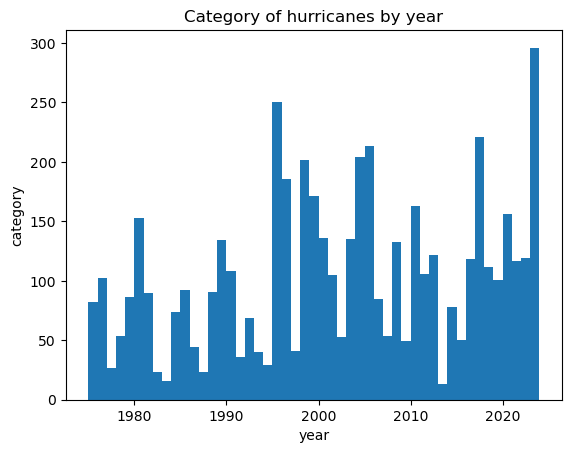

In [23]:
df2['year'].plot(kind = 'hist', bins = 49, title = 'Category of hurricanes by year', ylabel = 'category', xlabel = 'year')

AttributeError: module 'matplotlib' has no attribute 'title'

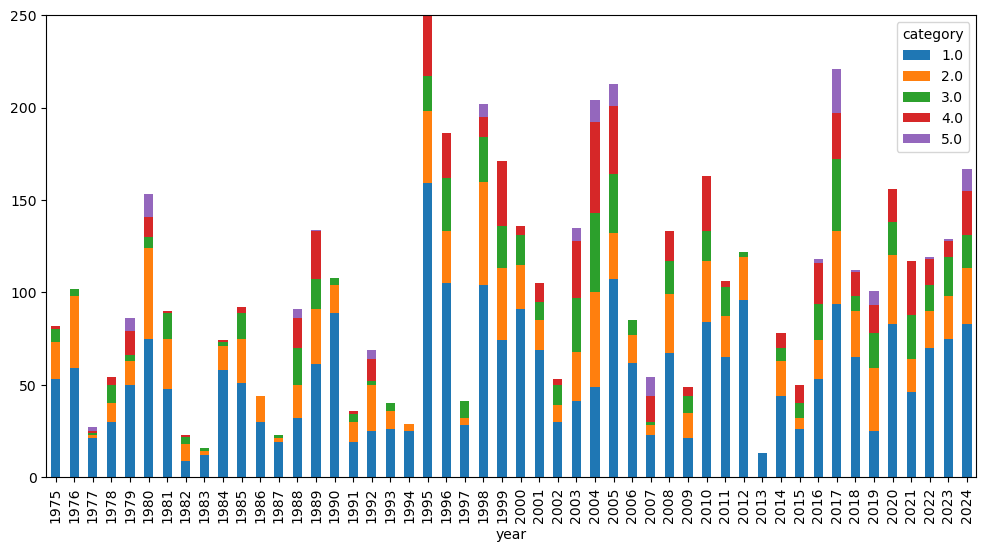

In [26]:
category_counts = df2.groupby(['year', 'category']).size().unstack(fill_value=0) 
## .unstack is used to reshape data (aka pivot) and move it from an inner level of the row index to the column headers
### useful when dealing with hiearachial data indices and also you to rearrange the data to make it easier to analyze
## .size is used to count the number of occurrences of each type of hurricane

category_counts.plot(kind='bar', stacked=True, figsize = (12,6)) 
## stacked = true makes the bars stacked on top of one anohter instead of side by side
plt.title('Category of hurricanes by year')
plt.ylabel('Hurricane count')
plt.xlabel('Year')
plt.legend(title='Category')
plt.show()

In [27]:
# Filter hurricanes in the Caribbean region
# Assuming 'lat' and 'long' columns represent latitude and longitude
# Typical Caribbean region: lat 9 to 23, long -89 to -60 (approximate bounds)

caribbean_df = df2[(df2['lat'] >= 9) & (df2['lat'] <= 23) & (df2['long'] >= -89) & (df2['long'] <= -60)]
caribbean_df.head()

,name,year,month,day,hour,lat,long,status,category,wind,pressure
226,Eloise,1975,9,16,18,19.5,-68.4,hurricane,1.0,65,1002.0
227,Eloise,1975,9,17,0,19.6,-69.2,hurricane,1.0,65,997.0
330,Gladys,1975,9,29,0,21.2,-60.3,hurricane,1.0,65,995.0
331,Gladys,1975,9,29,60,22.1,-61.4,hurricane,1.0,70,990.0
332,Gladys,1975,9,29,12,23.0,-62.6,hurricane,1.0,70,990.0


AttributeError: module 'matplotlib' has no attribute 'title'

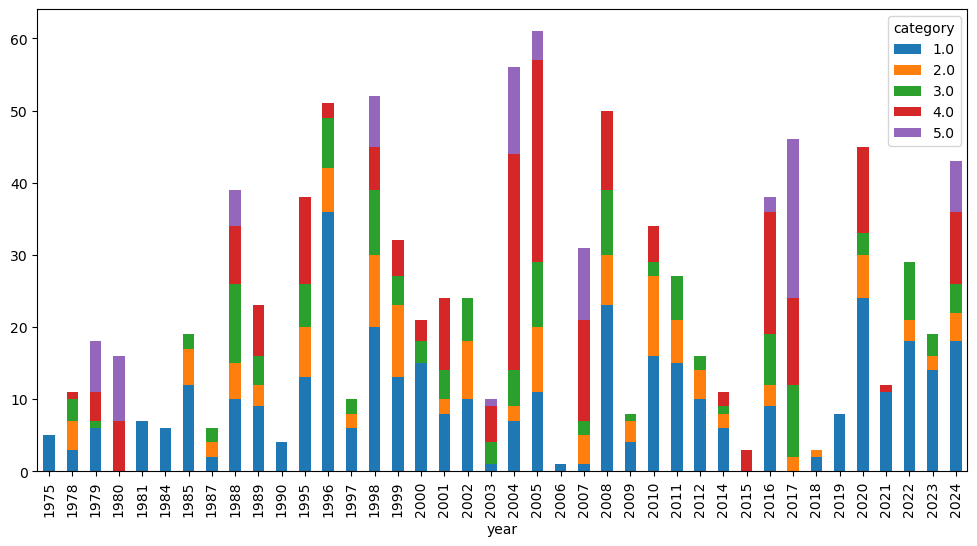

In [29]:
category_counts_caribbean = caribbean_df.groupby(['year', 'category']).size().unstack(fill_value=0)
category_counts_caribbean.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Caribbean Hurricane Category Count per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Category')
plt.show()

<Axes: title={'center': 'Average Hurricane Wind Speed in Caribbean by Year'}, xlabel='Year', ylabel='Average Wind Speed (kt)'>

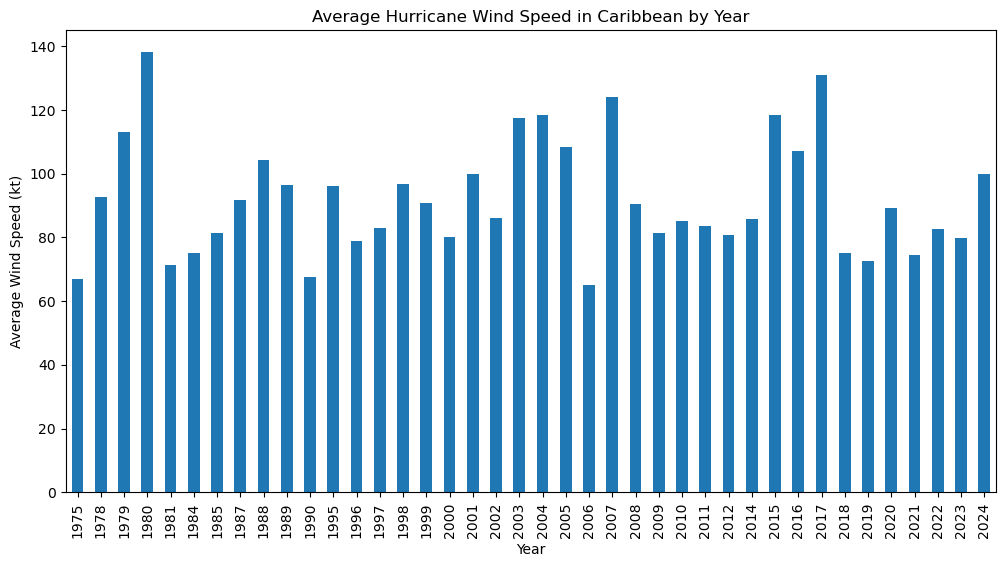

In [30]:
avg_wind_by_year = caribbean_df.groupby('year')['wind'].mean()
avg_wind_by_year.plot(
    kind='bar',
    figsize=(12, 6),
    title='Average Hurricane Wind Speed in Caribbean by Year',
    xlabel='Year',
    ylabel='Average Wind Speed (kt)'
)

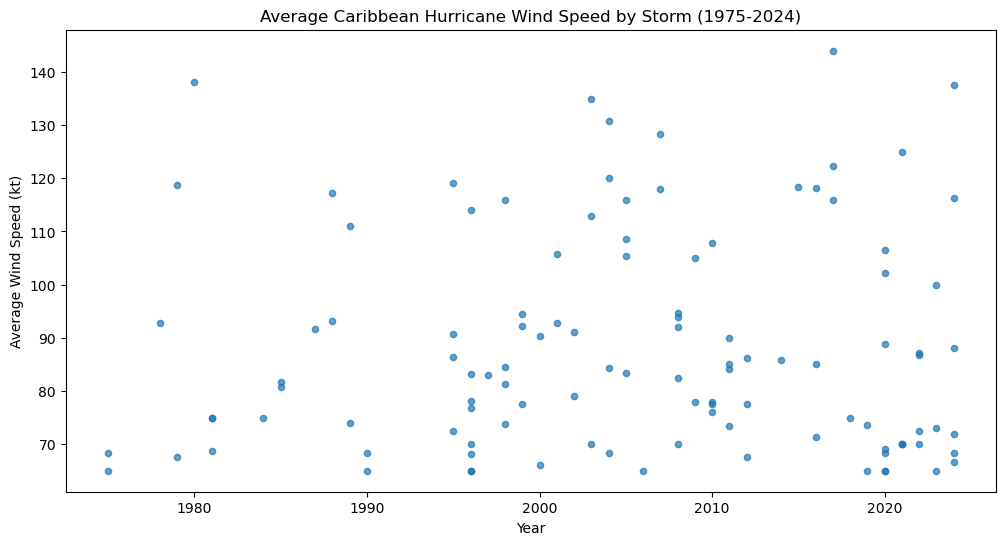

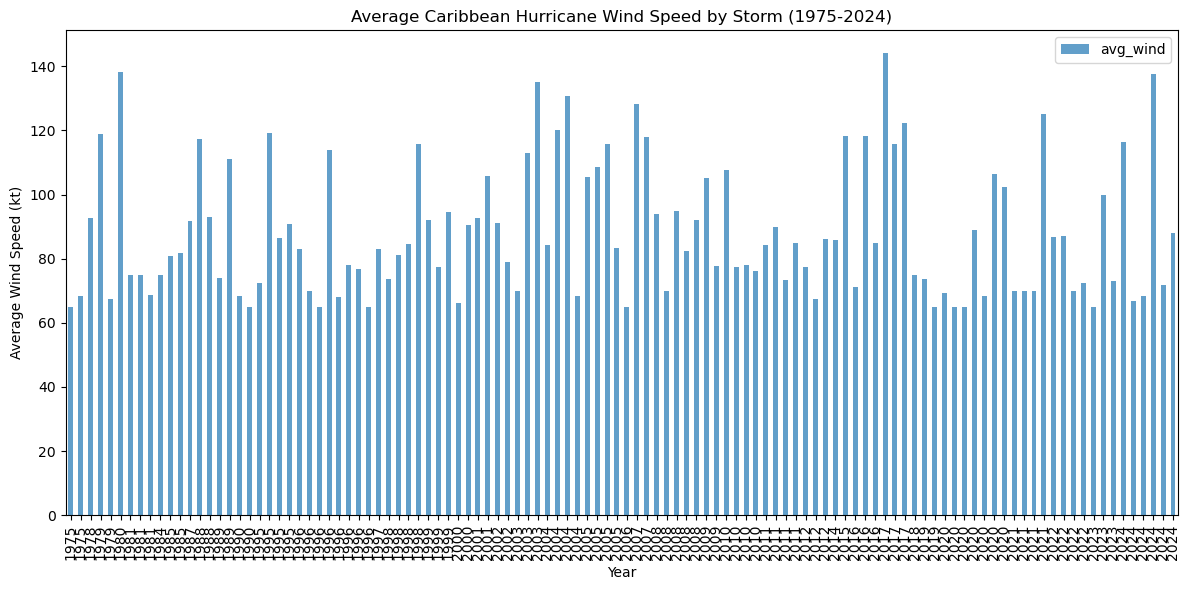

In [37]:
avg_wind_by_storm = (
    caribbean_df
    .groupby(['year', 'name'], sort=False)['wind']
    .mean()
    .reset_index(name='avg_wind')
)

ax = avg_wind_by_storm.plot(
    x='year',
    y='avg_wind',
    kind='scatter',
    figsize=(12, 6),
    title='Average Caribbean Hurricane Wind Speed by Storm (1975-2024)',
    xlabel='Year',
    ylabel='Average Wind Speed (kt)',
    alpha=0.7
)

avg_wind_by_storm = (
    caribbean_df
    .groupby(['year', 'name'], sort=False)['wind']
    .mean()
    .reset_index(name='avg_wind')
)

ax = avg_wind_by_storm.plot(
    x='year',
    y='avg_wind',
    kind='bar',
    figsize=(12, 6),
    title='Average Caribbean Hurricane Wind Speed by Storm (1975-2024)',
    xlabel='Year',
    ylabel='Average Wind Speed (kt)',
    alpha=0.7
)

ax.figure.tight_layout()
ax.figure.tight_layout()

AttributeError: module 'matplotlib' has no attribute 'show'

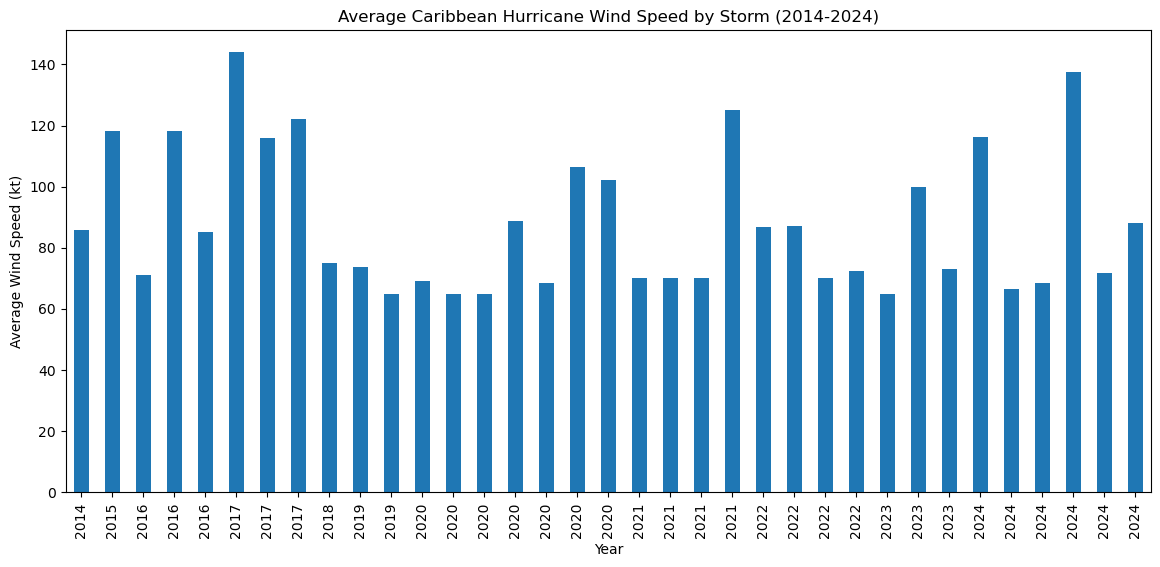

In [40]:
# Filter Caribbean hurricanes for years 2014-2024
caribbean_recent = caribbean_df[(caribbean_df['year'] >= 2014) & (caribbean_df['year'] <= 2024)]

# Calculate average wind speed per year
avg_wind_recent = caribbean_recent.groupby('year')['wind'].mean()

# Plot
avg_wind_by_storm_recent = (
    caribbean_recent
    .groupby(['year', 'name'], sort=False)['wind']
    .mean()
    .reset_index(name='avg_wind')
)

avg_wind_by_storm_recent.plot(
    x='year',
    y='avg_wind',
    kind='bar',
    figsize=(14, 6),
    title='Average Caribbean Hurricane Wind Speed by Storm (2014-2024)',
    xlabel='Year',
    ylabel='Average Wind Speed (kt)',
    legend=False
)
plt.show()

In [43]:
import pandas as pd

In [51]:
import os
print(os.listdir('10_years_water_temp.csv'))

FileNotFoundError: [Errno 2] No such file or directory: '10_years_water_temp.csv'

In [52]:
water_temp = pd.read_csv('ISAT 420/ISAT-Semester-Project/Code/10_years_temp.csv')
water_temp.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ISAT 420/ISAT-Semester-Project/Code/10_years_temp.csv'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Load the water temperature data
water_temp = pd.read_csv('/Users/jadawhite/Documents/GitHub/ISAT 420/ISAT-Semester-Project/Code/10 year.csv')

# Display first few rows to understand the structure
print(water_temp.head())
print("\nWater temp columns:", water_temp.columns.tolist())
print("Water temp shape:", water_temp.shape)

# Merge caribbean_recent with water_temp data
# Assuming water_temp has a 'year' column, we can merge on year
merged_data = caribbean_recent.merge(water_temp, on='year', how='inner')

# Calculate correlation between water temperature and wind speed
if 'temperature' in water_temp.columns:
    temp_col = 'temperature'
elif 'temp' in water_temp.columns:
    temp_col = 'temp'
else:
    temp_col = water_temp.columns[1]  # Use second column if unclear

correlation_wind_temp = merged_data['wind'].corr(merged_data[temp_col])
correlation_category_temp = merged_data['category'].corr(merged_data[temp_col])

print(f"\nCorrelation between water temperature and wind speed: {correlation_wind_temp:.4f}")
print(f"Correlation between water temperature and hurricane category: {correlation_category_temp:.4f}")

# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(merged_data[temp_col], merged_data['wind'], alpha=0.6)
axes[0].set_xlabel('Water Temperature')
axes[0].set_ylabel('Wind Speed (kt)')
axes[0].set_title(f'Water Temperature vs Wind Speed\n(Correlation: {correlation_wind_temp:.4f})')

axes[1].scatter(merged_data[temp_col], merged_data['category'], alpha=0.6)
axes[1].set_xlabel('Water Temperature')
axes[1].set_ylabel('Hurricane Category')
axes[1].set_title(f'Water Temperature vs Hurricane Category\n(Correlation: {correlation_category_temp:.4f})')

plt.tight_layout()
plt.show()

ParserError: Error tokenizing data. C error: Expected 1 fields in line 4, saw 2
